In [1]:
# Imports and reproducibility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [2]:
# Load the supplied dataset

DATA_PATH = "moviedata.csv"

data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
display(data.head())


Shape: (100000, 5)

Columns: ['Unnamed: 0', 'user', 'item', 'rating', 'ts']


,Unnamed: 0,user,item,rating,ts
0,0,0,0,3,881250949
1,1,1,1,3,891717742
2,2,2,2,1,878887116
3,3,3,3,2,880606923
4,4,4,4,1,886397596


In [3]:
# Basic data validation

print("Missing values:")
display(data.isna().sum())

print("Duplicate user-item pairs:", data.duplicated(["user", "item"]).sum())

print("\nNumber of unique users:", data["user"].nunique())
print("Number of unique items:", data["item"].nunique())
print("Rating range:", data["rating"].min(), "to", data["rating"].max())
print("\nRating counts:")
display(data["rating"].value_counts().sort_index())


Missing values:


Unnamed: 0    0
user          0
item          0
rating        0
ts            0
dtype: int64

Duplicate user-item pairs: 0

Number of unique users: 943
Number of unique items: 1682
Rating range: 1 to 5

Rating counts:


rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

#### 2. Preprocessing



In [4]:
# Keep only the information needed for collaborative filtering

data = data[["user", "item", "rating"]].copy()

# Make IDs explicit integer indices
data["user"] = data["user"].astype(int)
data["item"] = data["item"].astype(int)
data["rating"] = data["rating"].astype(float)

n_users = data["user"].nunique()
n_items = data["item"].nunique()

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Ratings: {len(data):,}")


Users: 943
Items: 1682
Ratings: 100,000


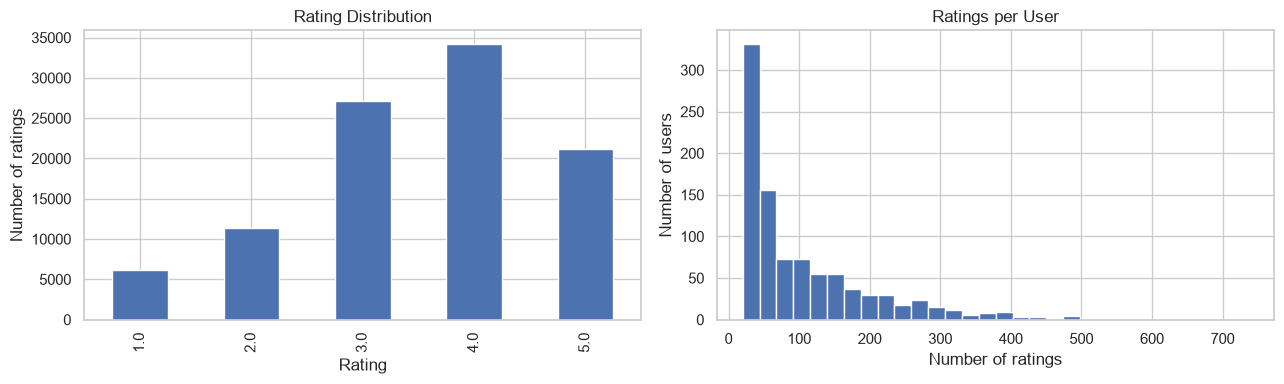

Interaction-matrix sparsity: 93.70%


In [5]:
# Exploratory analysis

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

data["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Rating Distribution"
)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of ratings")

user_counts = data.groupby("user").size()
axes[1].hist(user_counts, bins=30)
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Number of users")

plt.tight_layout()
plt.show()

sparsity = 1 - len(data) / (n_users * n_items)
print(f"Interaction-matrix sparsity: {sparsity:.2%}")


### Why sparsity matters

A recommendation dataset is normally sparse: most users have not rated most movies.

That matters because:

- memory-based methods depend on finding useful neighbors from overlapping ratings;
- matrix factorization can represent users and items using compact latent vectors, which can work better when the raw matrix is sparse.

We will test these ideas rather than assuming one method is automatically better.


## 3. Train / validation / test split

A random global split can accidentally leave some users without training ratings. Instead, we split **inside each user**:

- 80% → train
- 10% → validation
- 10% → test


In [6]:
def per_user_split(df, train_frac=0.80, val_frac=0.10, test_frac=0.10, seed=42):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-9

    rng = np.random.default_rng(seed)
    train_parts, val_parts, test_parts = [], [], []

    for _, group in df.groupby("user"):
        idx = np.arange(len(group))
        rng.shuffle(idx)

        n = len(group)
        n_test = max(1, int(round(test_frac * n)))
        n_val = max(1, int(round(val_frac * n)))

        # Keep at least one training interaction when possible
        if n - n_test - n_val < 1:
            n_val = 1
            n_test = 1

        test_idx = idx[:n_test]
        val_idx = idx[n_test:n_test + n_val]
        train_idx = idx[n_test + n_val:]

        train_parts.append(group.iloc[train_idx])
        val_parts.append(group.iloc[val_idx])
        test_parts.append(group.iloc[test_idx])

    return (
        pd.concat(train_parts).reset_index(drop=True),
        pd.concat(val_parts).reset_index(drop=True),
        pd.concat(test_parts).reset_index(drop=True)
    )


train, val, test = per_user_split(data, seed=SEED)

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nUsers in each split:")
print(
    "Train:", train["user"].nunique(),
    "| Val:", val["user"].nunique(),
    "| Test:", test["user"].nunique()
)


Train: (80024, 3)
Validation: (9988, 3)
Test: (9988, 3)

Users in each split:
Train: 943 | Val: 943 | Test: 943


In [7]:
# Confirm there is no overlap of the exact same user-item interaction across splits

def interaction_keys(df):
    return set(zip(df["user"].astype(int), df["item"].astype(int)))

train_keys = interaction_keys(train)
val_keys = interaction_keys(val)
test_keys = interaction_keys(test)

print("Train ∩ Val:", len(train_keys & val_keys))
print("Train ∩ Test:", len(train_keys & test_keys))
print("Val ∩ Test:", len(val_keys & test_keys))


Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


#### 4. Baseline model


In [8]:
global_mean = train["rating"].mean()

baseline_pred = np.full(len(test), global_mean)

baseline_rmse = mean_squared_error(test["rating"], baseline_pred) ** 0.5
baseline_mae = mean_absolute_error(test["rating"], baseline_pred)

print(f"Global mean: {global_mean:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE : {baseline_mae:.4f}")


Global mean: 3.5310
Baseline RMSE: 1.1259
Baseline MAE : 0.9468


# Part A — Memory-Based Collaborative Filtering

We use **user-user collaborative filtering**.

### Idea

Two users are similar if their rating patterns are similar.

For a target user `u` and an unrated movie `i`:

1. find users similar to `u`;
2. keep the top `k` neighbors;
3. use neighbors who rated movie `i`;
4. calculate a similarity-weighted prediction.

We center each user's ratings by their own mean before computing cosine similarity. This prevents a user who generally gives high ratings from looking similar to everyone simply because their ratings are numerically larger.

The prediction is approximately:

\[
\hat r_{ui} =
\bar r_u +
\frac{\sum_{v \in N(u,i)} s(u,v)(r_{vi}-\bar r_v)}
{\sum_{v \in N(u,i)} |s(u,v)|}
\]

where `s(u,v)` is user similarity.


In [9]:
# Build the training interaction matrix

train_matrix = (
    train.pivot(index="user", columns="item", values="rating")
         .reindex(index=range(n_users), columns=range(n_items))
)

# User means are calculated using TRAINING ratings only.
user_means = train.groupby("user")["rating"].mean().reindex(range(n_users))
user_means = user_means.fillna(global_mean)

# Mean-center only observed ratings.
centered = train_matrix.sub(user_means, axis=0).fillna(0)

# User-user cosine similarity.
user_similarity = cosine_similarity(centered)

# A user should not be their own neighbor.
np.fill_diagonal(user_similarity, 0)

print("Interaction matrix shape:", train_matrix.shape)
print("Similarity matrix shape:", user_similarity.shape)


Interaction matrix shape: (943, 1682)
Similarity matrix shape: (943, 943)


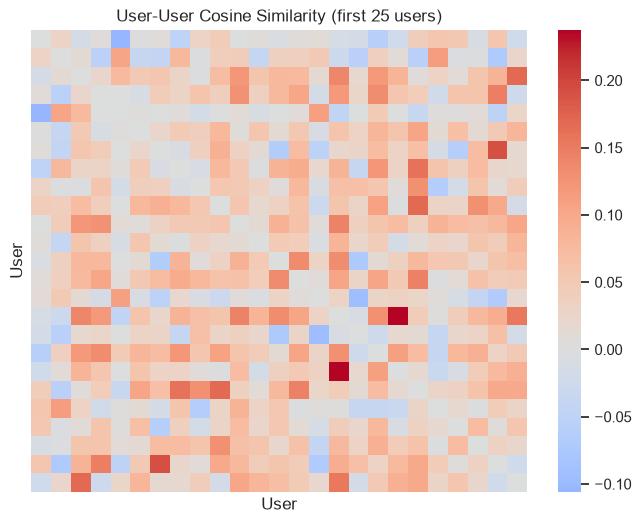

In [10]:
# Visualize a small part of the user-user similarity matrix

plt.figure(figsize=(8, 6))
sns.heatmap(
    user_similarity[:25, :25],
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)
plt.title("User-User Cosine Similarity (first 25 users)")
plt.xlabel("User")
plt.ylabel("User")
plt.show()


In [11]:
def get_top_neighbors(similarity_matrix, k):
    # Return the indices of the k most similar users for every user.
    return np.argsort(-similarity_matrix, axis=1)[:, :k]


def predict_user_cf(ratings_to_predict, k=30, min_similarity=0.0):
    """Predict ratings using user-based memory CF.

    All statistics and similarities come from TRAIN only.
    """
    neighbors = get_top_neighbors(user_similarity, k)

    predictions = []

    for row in ratings_to_predict.itertuples(index=False):
        u = int(row.user)
        i = int(row.item)

        neighbor_ids = neighbors[u]
        sims = user_similarity[u, neighbor_ids]

        # Keep only positive similarities above the threshold.
        valid = sims > min_similarity
        neighbor_ids = neighbor_ids[valid]
        sims = sims[valid]

        if len(neighbor_ids) == 0:
            predictions.append(user_means.iloc[u])
            continue

        # Ratings of these neighbors for item i.
        neighbor_ratings = train_matrix.iloc[neighbor_ids, i].to_numpy()
        rated = ~np.isnan(neighbor_ratings)

        neighbor_ids = neighbor_ids[rated]
        sims = sims[rated]
        neighbor_ratings = neighbor_ratings[rated]

        if len(neighbor_ids) == 0 or np.sum(np.abs(sims)) == 0:
            predictions.append(user_means.iloc[u])
            continue

        neighbor_mean_values = user_means.iloc[neighbor_ids].to_numpy()
        deviations = neighbor_ratings - neighbor_mean_values

        pred = user_means.iloc[u] + np.sum(sims * deviations) / np.sum(np.abs(sims))
        predictions.append(pred)

    return np.clip(np.asarray(predictions), 1.0, 5.0)


## 5. Select the number of neighbors using validation data

`k` controls how many similar users influence a prediction.

- Very small `k`: can be noisy.
- Very large `k`: can include weakly related users.

We select `k` using **validation RMSE**, not test RMSE.


In [12]:
candidate_k = [5, 10, 20, 30, 50]

memory_validation_results = []

for k in candidate_k:
    val_pred = predict_user_cf(val, k=k)
    rmse = mean_squared_error(val["rating"], val_pred) ** 0.5
    mae = mean_absolute_error(val["rating"], val_pred)

    memory_validation_results.append({
        "k": k,
        "RMSE": rmse,
        "MAE": mae
    })

memory_validation_results = pd.DataFrame(memory_validation_results)
display(memory_validation_results)

best_k = int(
    memory_validation_results.loc[
        memory_validation_results["RMSE"].idxmin(), "k"
    ]
)

print("Selected k:", best_k)


,k,RMSE,MAE
0,5,1.071303,0.838499
1,10,1.052721,0.818321
2,20,1.016592,0.787339
3,30,0.995846,0.769878
4,50,0.974243,0.754222


Selected k: 50


In [13]:
# Final memory-based evaluation on the untouched test set

memory_test_pred = predict_user_cf(test, k=best_k)

memory_rmse = mean_squared_error(test["rating"], memory_test_pred) ** 0.5
memory_mae = mean_absolute_error(test["rating"], memory_test_pred)

print(f"Memory-based ({best_k} neighbors) RMSE: {memory_rmse:.4f}")
print(f"Memory-based ({best_k} neighbors) MAE : {memory_mae:.4f}")


Memory-based (50 neighbors) RMSE: 0.9637
Memory-based (50 neighbors) MAE : 0.7494


# Part B — Model-Based Collaborative Filtering

## Matrix Factorization from scratch

Instead of storing the whole rating pattern directly, matrix factorization learns a smaller vector for every user and item.

For user `u` and item `i`:

\[
\hat r_{ui} =
μ + b_u + b_i + p_u^Tq_i
\]

where:

- `μ` = global mean
- `b_u` = user bias
- `b_i` = item bias
- `p_u` = latent vector for user `u`
- `q_i` = latent vector for item `i`

We train these parameters with **stochastic gradient descent (SGD)** on the training ratings only.

This is implemented directly below; no pretrained recommendation weights are used.


In [14]:
def rmse_from_arrays(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mf_predict(users, items, global_mean, user_bias, item_bias, user_factors, item_factors):
    return (
        global_mean
        + user_bias[users]
        + item_bias[items]
        + np.sum(user_factors[users] * item_factors[items], axis=1)
    )


def train_matrix_factorization(
    train_df,
    val_df,
    n_users,
    n_items,
    n_factors=30,
    epochs=20,
    learning_rate=0.005,
    reg=0.02,
    seed=42
):
    rng = np.random.default_rng(seed)

    users = train_df["user"].to_numpy(dtype=np.int64)
    items = train_df["item"].to_numpy(dtype=np.int64)
    ratings = train_df["rating"].to_numpy(dtype=np.float64)

    val_users = val_df["user"].to_numpy(dtype=np.int64)
    val_items = val_df["item"].to_numpy(dtype=np.int64)
    val_ratings = val_df["rating"].to_numpy(dtype=np.float64)

    global_mean = ratings.mean()

    # Small random initialization.
    user_factors = rng.normal(0, 0.05, size=(n_users, n_factors))
    item_factors = rng.normal(0, 0.05, size=(n_items, n_factors))

    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_items)

    history = []
    best_val_rmse = np.inf
    best_state = None
    patience = 3
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(train_df))

        for idx in order:
            u = users[idx]
            i = items[idx]
            r = ratings[idx]

            pred = (
                global_mean
                + user_bias[u]
                + item_bias[i]
                + np.dot(user_factors[u], item_factors[i])
            )

            error = r - pred

            # Save old vectors because both updates should use the same old values.
            pu_old = user_factors[u].copy()
            qi_old = item_factors[i].copy()

            user_bias[u] += learning_rate * (error - reg * user_bias[u])
            item_bias[i] += learning_rate * (error - reg * item_bias[i])

            user_factors[u] += learning_rate * (
                error * qi_old - reg * pu_old
            )
            item_factors[i] += learning_rate * (
                error * pu_old - reg * qi_old
            )

        # Training and validation metrics after each epoch.
        train_pred = mf_predict(
            users, items, global_mean,
            user_bias, item_bias, user_factors, item_factors
        )
        val_pred = mf_predict(
            val_users, val_items, global_mean,
            user_bias, item_bias, user_factors, item_factors
        )

        train_rmse = rmse_from_arrays(ratings, train_pred)
        val_rmse = rmse_from_arrays(val_ratings, val_pred)

        history.append({
            "epoch": epoch,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse
        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train RMSE: {train_rmse:.4f} | "
            f"Val RMSE: {val_rmse:.4f}"
        )

        # Early stopping and best-model checkpoint.
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = (
                user_bias.copy(),
                item_bias.copy(),
                user_factors.copy(),
                item_factors.copy()
            )
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    # Restore the best validation model.
    user_bias, item_bias, user_factors, item_factors = best_state

    return {
        "global_mean": global_mean,
        "user_bias": user_bias,
        "item_bias": item_bias,
        "user_factors": user_factors,
        "item_factors": item_factors,
        "history": pd.DataFrame(history)
    }


## 6. Matrix-factorization model selection

We use the validation set to compare a few latent-factor sizes.

The final test set is still untouched.

To keep runtime reasonable, the search is intentionally small. For a larger project, you could search more combinations of factors, learning rate, and regularization.


In [15]:
mf_candidates = [
    {"n_factors": 20, "learning_rate": 0.005, "reg": 0.02},
    {"n_factors": 30, "learning_rate": 0.005, "reg": 0.02},
    {"n_factors": 50, "learning_rate": 0.005, "reg": 0.02},
]

mf_validation_results = []
mf_models = {}

for cfg in mf_candidates:
    print("\n" + "=" * 70)
    print("Testing:", cfg)

    model = train_matrix_factorization(
        train,
        val,
        n_users=n_users,
        n_items=n_items,
        n_factors=cfg["n_factors"],
        epochs=20,
        learning_rate=cfg["learning_rate"],
        reg=cfg["reg"],
        seed=SEED
    )

    val_pred = mf_predict(
        val["user"].to_numpy(),
        val["item"].to_numpy(),
        model["global_mean"],
        model["user_bias"],
        model["item_bias"],
        model["user_factors"],
        model["item_factors"]
    )

    val_rmse = rmse_from_arrays(val["rating"].to_numpy(), val_pred)
    val_mae = mean_absolute_error(val["rating"], val_pred)

    key = str(cfg)
    mf_models[key] = model

    mf_validation_results.append({
        **cfg,
        "RMSE": val_rmse,
        "MAE": val_mae
    })

mf_validation_results = pd.DataFrame(mf_validation_results)
display(mf_validation_results)

best_mf_row = mf_validation_results.loc[mf_validation_results["RMSE"].idxmin()]
best_mf_config = {
    "n_factors": int(best_mf_row["n_factors"]),
    "learning_rate": float(best_mf_row["learning_rate"]),
    "reg": float(best_mf_row["reg"])
}

print("Selected configuration:", best_mf_config)



Testing: {'n_factors': 20, 'learning_rate': 0.005, 'reg': 0.02}
Epoch 01/20 | Train RMSE: 0.9971 | Val RMSE: 0.9988
Epoch 02/20 | Train RMSE: 0.9652 | Val RMSE: 0.9736
Epoch 03/20 | Train RMSE: 0.9500 | Val RMSE: 0.9628
Epoch 04/20 | Train RMSE: 0.9408 | Val RMSE: 0.9565
Epoch 05/20 | Train RMSE: 0.9343 | Val RMSE: 0.9527
Epoch 06/20 | Train RMSE: 0.9296 | Val RMSE: 0.9503
Epoch 07/20 | Train RMSE: 0.9259 | Val RMSE: 0.9483
Epoch 08/20 | Train RMSE: 0.9228 | Val RMSE: 0.9471
Epoch 09/20 | Train RMSE: 0.9202 | Val RMSE: 0.9461
Epoch 10/20 | Train RMSE: 0.9180 | Val RMSE: 0.9452
Epoch 11/20 | Train RMSE: 0.9158 | Val RMSE: 0.9446
Epoch 12/20 | Train RMSE: 0.9138 | Val RMSE: 0.9441
Epoch 13/20 | Train RMSE: 0.9116 | Val RMSE: 0.9433
Epoch 14/20 | Train RMSE: 0.9096 | Val RMSE: 0.9427
Epoch 15/20 | Train RMSE: 0.9074 | Val RMSE: 0.9423
Epoch 16/20 | Train RMSE: 0.9049 | Val RMSE: 0.9420
Epoch 17/20 | Train RMSE: 0.9022 | Val RMSE: 0.9413
Epoch 18/20 | Train RMSE: 0.8992 | Val RMSE: 0.9408

,n_factors,learning_rate,reg,RMSE,MAE
0,20,0.005,0.02,0.939040,0.738986
1,30,0.005,0.02,0.935095,0.735779
2,50,0.005,0.02,0.930158,0.731464


Selected configuration: {'n_factors': 50, 'learning_rate': 0.005, 'reg': 0.02}


### Important note about the validation procedure

The code above trains each candidate using the same training split and evaluates it on the same validation split.

After choosing the best configuration, we train the final model again using the training data and use the validation data for early stopping. The test set remains untouched until the final comparison.


In [16]:
# Train the selected matrix-factorization configuration

best_mf_model = train_matrix_factorization(
    train,
    val,
    n_users=n_users,
    n_items=n_items,
    n_factors=best_mf_config["n_factors"],
    epochs=30,
    learning_rate=best_mf_config["learning_rate"],
    reg=best_mf_config["reg"],
    seed=SEED
)

history = best_mf_model["history"]
display(history.tail())


Epoch 01/30 | Train RMSE: 0.9963 | Val RMSE: 0.9991
Epoch 02/30 | Train RMSE: 0.9638 | Val RMSE: 0.9738
Epoch 03/30 | Train RMSE: 0.9480 | Val RMSE: 0.9627
Epoch 04/30 | Train RMSE: 0.9380 | Val RMSE: 0.9566
Epoch 05/30 | Train RMSE: 0.9309 | Val RMSE: 0.9526
Epoch 06/30 | Train RMSE: 0.9253 | Val RMSE: 0.9500
Epoch 07/30 | Train RMSE: 0.9207 | Val RMSE: 0.9478
Epoch 08/30 | Train RMSE: 0.9167 | Val RMSE: 0.9468
Epoch 09/30 | Train RMSE: 0.9129 | Val RMSE: 0.9457
Epoch 10/30 | Train RMSE: 0.9093 | Val RMSE: 0.9445
Epoch 11/30 | Train RMSE: 0.9056 | Val RMSE: 0.9435
Epoch 12/30 | Train RMSE: 0.9017 | Val RMSE: 0.9425
Epoch 13/30 | Train RMSE: 0.8975 | Val RMSE: 0.9413
Epoch 14/30 | Train RMSE: 0.8930 | Val RMSE: 0.9401
Epoch 15/30 | Train RMSE: 0.8878 | Val RMSE: 0.9388
Epoch 16/30 | Train RMSE: 0.8820 | Val RMSE: 0.9374
Epoch 17/30 | Train RMSE: 0.8755 | Val RMSE: 0.9360
Epoch 18/30 | Train RMSE: 0.8683 | Val RMSE: 0.9340
Epoch 19/30 | Train RMSE: 0.8602 | Val RMSE: 0.9321
Epoch 20/30 

,epoch,train_rmse,val_rmse
25,26,0.787973,0.919767
26,27,0.776279,0.918843
27,28,0.764365,0.918009
28,29,0.752348,0.917520
29,30,0.740238,0.917295


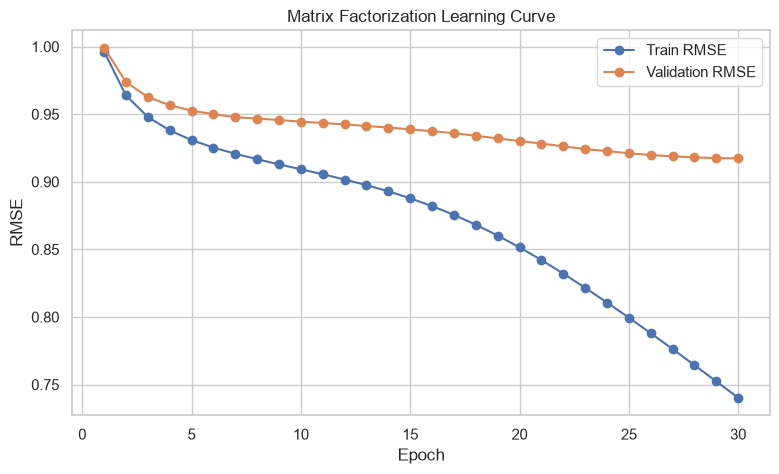

In [17]:
# Plot matrix-factorization training progress

plt.figure(figsize=(9, 5))
plt.plot(history["epoch"], history["train_rmse"], marker="o", label="Train RMSE")
plt.plot(history["epoch"], history["val_rmse"], marker="o", label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Matrix Factorization Learning Curve")
plt.legend()
plt.show()


In [18]:
# Final model-based evaluation on the untouched test set

mf_test_pred = mf_predict(
    test["user"].to_numpy(),
    test["item"].to_numpy(),
    best_mf_model["global_mean"],
    best_mf_model["user_bias"],
    best_mf_model["item_bias"],
    best_mf_model["user_factors"],
    best_mf_model["item_factors"]
)

mf_test_pred = np.clip(mf_test_pred, 1.0, 5.0)

mf_rmse = mean_squared_error(test["rating"], mf_test_pred) ** 0.5
mf_mae = mean_absolute_error(test["rating"], mf_test_pred)

print(f"Matrix Factorization RMSE: {mf_rmse:.4f}")
print(f"Matrix Factorization MAE : {mf_mae:.4f}")


Matrix Factorization RMSE: 0.9166
Matrix Factorization MAE : 0.7233


# 7. Final comparison

Lower **RMSE** and **MAE** are better.

The baseline, memory-based model, and matrix-factorization model are all evaluated on the **same test interactions**.


In [19]:
results = pd.DataFrame([
    {
        "Model": "Global Mean Baseline",
        "RMSE": baseline_rmse,
        "MAE": baseline_mae
    },
    {
        "Model": f"Memory-Based User CF (k={best_k})",
        "RMSE": memory_rmse,
        "MAE": memory_mae
    },
    {
        "Model": f"Matrix Factorization ({best_mf_config['n_factors']} factors)",
        "RMSE": mf_rmse,
        "MAE": mf_mae
    }
])

display(results.round(4))


,Model,RMSE,MAE
0,Global Mean Baseline,1.1259,0.9468
1,Memory-Based User CF (k=50),0.9637,0.7494
2,Matrix Factorization (50 factors),0.9166,0.7233


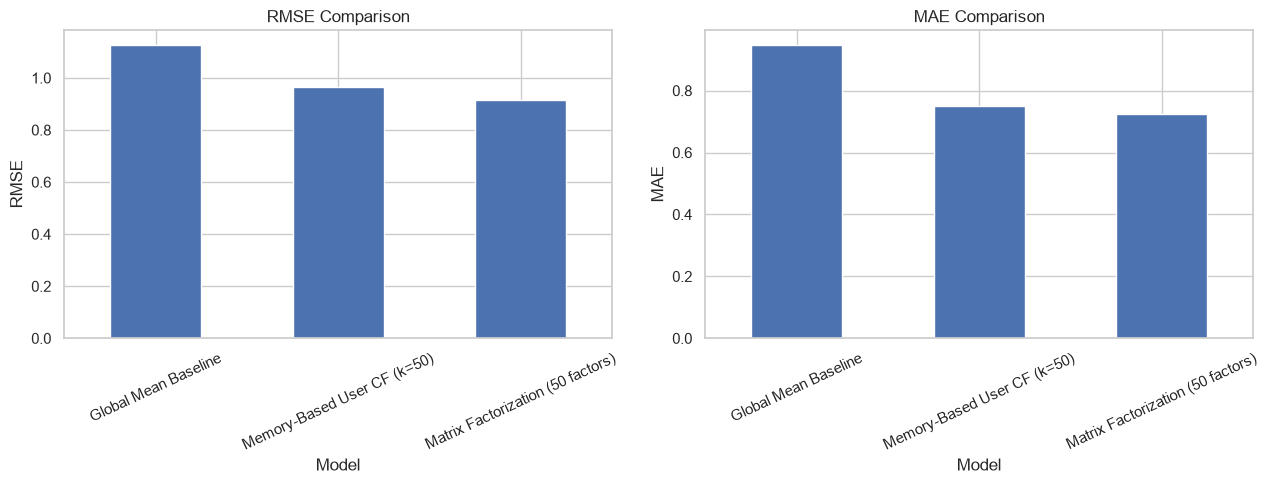

In [20]:
# Comparison plots

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results.plot(
    x="Model", y="RMSE", kind="bar", ax=axes[0], legend=False
)
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=25)

results.plot(
    x="Model", y="MAE", kind="bar", ax=axes[1], legend=False
)
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


# 8. Example recommendations

A rating predictor and a recommendation system are related but not identical.

For recommendations, we:

1. choose a user;
2. find movies the user has **not rated in the training data**;
3. predict ratings for those movies;
4. return the highest predicted ratings.

Because the supplied CSV contains only IDs rather than movie titles, the recommendations below are shown using **item IDs**.


In [21]:
def recommend_mf(user_id, model, train_df, n=10):
    rated_items = set(train_df.loc[train_df["user"] == user_id, "item"])

    all_items = np.arange(n_items)
    candidate_items = np.array([i for i in all_items if i not in rated_items])

    users = np.full(len(candidate_items), user_id)

    predictions = mf_predict(
        users,
        candidate_items,
        model["global_mean"],
        model["user_bias"],
        model["item_bias"],
        model["user_factors"],
        model["item_factors"]
    )

    recommendations = pd.DataFrame({
        "item": candidate_items,
        "predicted_rating": np.clip(predictions, 1, 5)
    })

    return recommendations.sort_values(
        "predicted_rating", ascending=False
    ).head(n).reset_index(drop=True)


example_user = int(test["user"].iloc[0])

print("Example user:", example_user)
display(recommend_mf(example_user, best_mf_model, train, n=10))


Example user: 0


,item,predicted_rating
0,277,4.555364
1,612,4.496614
2,180,4.453588
3,200,4.442526
4,78,4.428980
5,174,4.426675
6,1255,4.404294
7,185,4.401493
8,297,4.342502
9,239,4.342441


# 9. Conclusion

Use the numbers produced above when writing the final conclusion; do **not** manually invent results.

A good interpretation should cover:

### Memory-based collaborative filtering

**Advantages**
- simple and intuitive;
- recommendations are directly based on similar users;
- easy to explain;
- no lengthy parameter-training process.

**Limitations**
- similarity computation can become expensive as the number of users/items grows;
- sparse data can make it difficult to find strong neighbors;
- recommendations can depend heavily on the quality of neighborhood overlap.

### Matrix factorization

**Advantages**
- compresses users and items into compact latent vectors;
- can discover hidden preference patterns that are not obvious from direct similarity;
- scales more naturally than storing all pairwise user similarities for large systems.

**Limitations**
- requires model training and hyperparameter choices;
- latent factors are less interpretable;
- cold-start users/items remain a problem because there is little interaction history.

### What to report

1. Dataset: 100K ratings, 943 users, 1,682 items.
2. Split: 80% train / 10% validation / 10% test per user.
3. Memory method: user-user cosine similarity with the validation-selected `k`.
4. Model method: matrix factorization trained from scratch with SGD.
5. Metrics: test RMSE and MAE.
6. Which method achieved the lower test error.
7. Why the result makes sense for this sparse user-item setting.

The task requires a results table, plots, preprocessing/split decisions, comparison, and a conclusion about when memory-based or model-based methods are preferable; this notebook covers those deliverables. fileciteturn0file0L20-L29
